In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings 
warnings.filterwarnings("ignore")




df = pd.read_csv("IPL.csv")
df.head()


,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   match_id             74 non-null     int64
 1   date                 74 non-null     str  
 2   venue                74 non-null     str  
 3   team1                74 non-null     str  
 4   team2                74 non-null     str  
 5   stage                74 non-null     str  
 6   toss_winner          74 non-null     str  
 7   toss_decision        74 non-null     str  
 8   first_ings_score     74 non-null     int64
 9   first_ings_wkts      74 non-null     int64
 10  second_ings_score    74 non-null     int64
 11  second_ings_wkts     74 non-null     int64
 12  match_winner         74 non-null     str  
 13  won_by               74 non-null     str  
 14  margin               74 non-null     int64
 15  player_of_the_match  74 non-null     str  
 16  top_scorer           74 non-null     st

In [11]:
df.shape

(74, 20)

In [12]:
df.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

<Axes: ylabel='match_winner'>

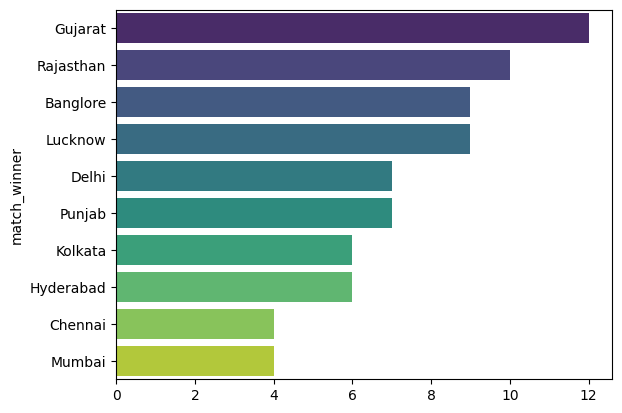

In [27]:
#which team won the most matches?
match_win=df["match_winner"].value_counts()
sns.barplot(x=match_win.values, y=match_win.index, palette='viridis')


Text(0.5, 1.0, 'Toss decision trends')

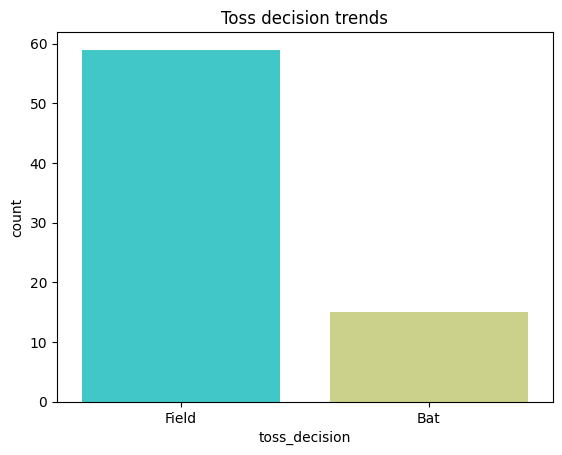

In [30]:
#Toss Decision Trends
sns.countplot(x='toss_decision', data=df, palette= "rainbow")
plt.title("Toss decision trends")

In [46]:
#Toss winner vs Match winner 
# sns.countplot(x="match_winner",hue="toss_winner",data=df)
count=df[df["toss_winner"]==df["match_winner"]]["match_id"].count()
percentage=(count*100)/df.shape[0]
percentage.round()


np.float64(49.0)

Text(0.5, 1.0, 'Won by')

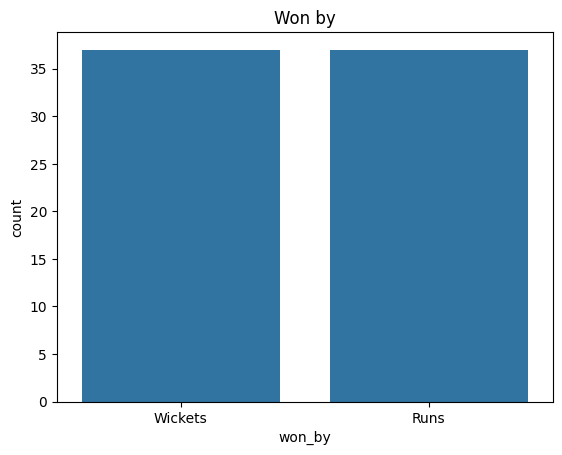

In [49]:
#how do teams won(runs vs wickets)?
sns.countplot(x="won_by", data=df)
plt.title("Won by")

key player performance 


Text(0.5, 1.0, 'top 10 players')

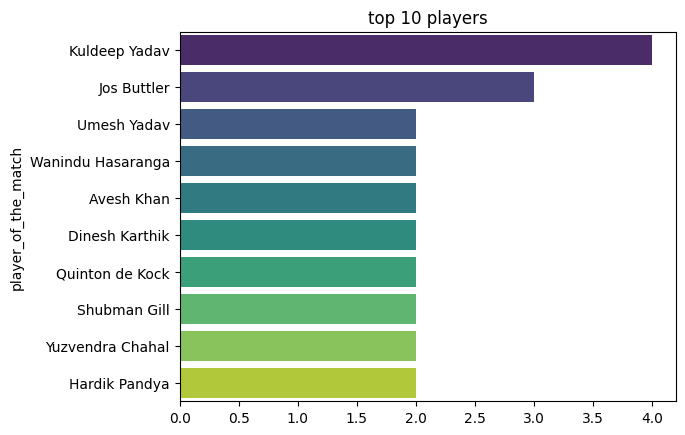

In [57]:
#most player of the match
count=df['player_of_the_match'].value_counts().head(10)
sns.barplot(x=count.values, y=count.index, palette="viridis")
plt.title("top 10 players")

<Axes: ylabel='top_scorer'>

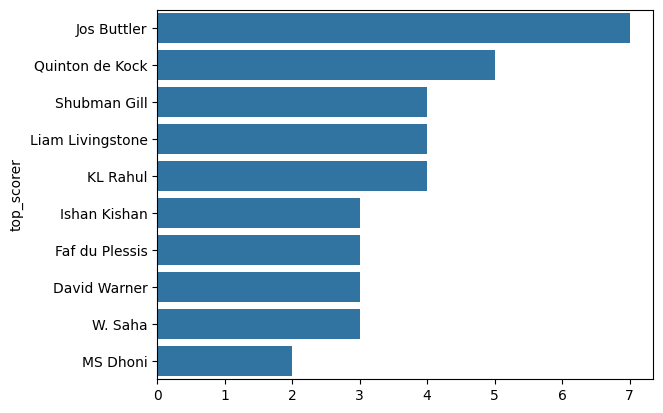

In [66]:
#top scorers
top =df["top_scorer"].value_counts().head(10)

sns.barplot(x=top.values,y=top.index)

<Axes: ylabel='top_scorer'>

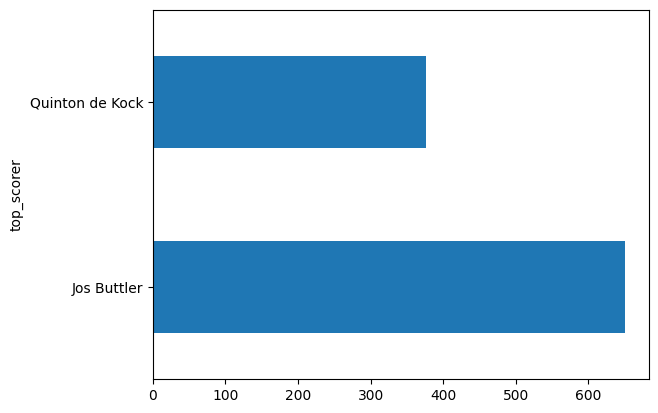

In [73]:
high =df.groupby('top_scorer')["highscore"].sum().sort_values(ascending=False).head(2)
high.plot(kind="barh")

In [80]:
# #best bowling figures
# bb=df.groupby('best_bowling')["best_bowling_figure"].value_counts().head(10)
# bb
df['highest_wickets']=df['best_bowling_figure'].apply(lambda x:x.split('--')[0])
df["highest_wickets"]=df["highest_wickets"].astype("int")
df["highest_wickets"].dtype

dtype('int64')

<Axes: ylabel='best_bowling'>

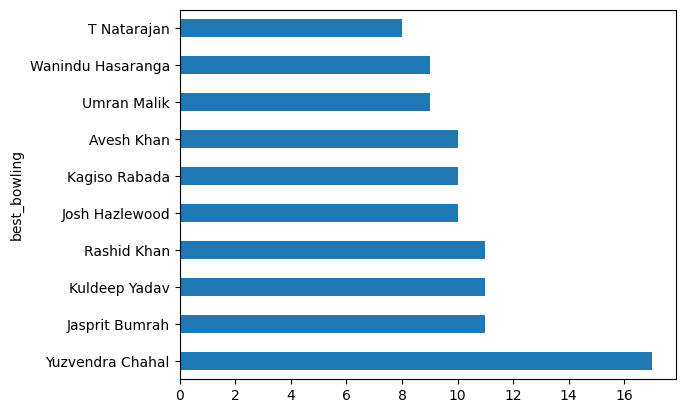

In [87]:
bb=df.groupby('best_bowling')["highest_wickets"].sum().sort_values(ascending=False).head(10)
bb.plot(kind="barh")

In [91]:
#most matches played by venue
counts=df['venue'].value_counts()
counts

venue
Wankhede Stadium, Mumbai                        21
Dr DY Patil Sports Academy, Mumbai              20
Brabourne Stadium, Mumbai                       16
Maharashtra Cricket Association Stadium,Pune    13
Eden Gardens, Kolkata                            2
Narendra Modi Stadium, Ahmedabad                 2
Name: count, dtype: int64

<Axes: ylabel='venue'>

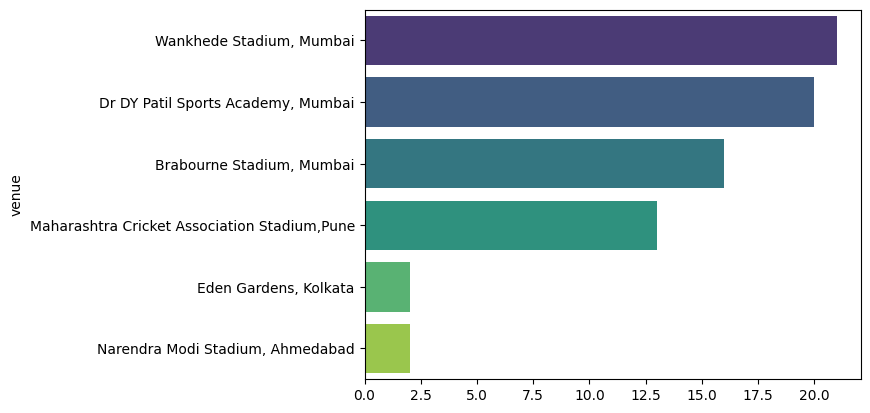

In [93]:
sns.barplot(x=counts.values,y=counts.index,palette="viridis")

In [97]:
#who won the highest margin by runs?
df[df["won_by"]== "Runs"].sort_values(by="margin",ascending=False).head(1)[["match_winner","margin"]]

,match_winner,margin
54,Chennai,91


In [98]:
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,highest_wickets
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,...,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20,3
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,...,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18,3
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,...,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59,2
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,...,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25,3
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,...,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22,3


In [106]:
hs=df[df["highscore"]==df["highscore"].max()][["top_scorer","highscore"]]
hs


,top_scorer,highscore
65,Quinton de Kock,140
